# ALS Recommender System Project

This notebook implements an implicit-feedback recommender system using the **ALS (Alternating Least Squares)** algorithm from the `implicit` library.

We:

- Load the `train-1.txt` file (user–item implicit interactions)
- Do basic preprocessing (remove very rare items)
- Explore the data with simple EDA plots
- Perform a 90/10 per-user train–validation split
- Train **one base ALS model** and **two tweaks**:
  - **Base ALS**: default hyperparameters
  - **Tweak 1**: deeper model (more factors, stronger regularization)
  - **Tweak 2**: same idea but with **BM25 reweighting** of interactions
- Evaluate models using **NDCG@20**
- Select the best variant and retrain it on the full preprocessed data
- Generate a `submission.txt` file in the required format


In [14]:
import numpy as np
import random
from collections import defaultdict

from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt

import implicit
from implicit.nearest_neighbours import bm25_weight

# ---------------- Config ----------------
DATA_PATH = "train-1.txt"   # make sure this file is in the same folder
K_RECS = 20                  # top-K recommendations
VAL_FRAC = 0.1               # 90/10 train/val split
RANDOM_SEED = 42


## 1. Load interactions

The dataset contains **implicit positive feedback**:

- Each row: `user_id item1 item2 item3 ...`
- We map raw user IDs and item IDs into **0-based indices**
- We build a **user–item CSR matrix** of shape `(n_users, n_items)` where each non-zero entry indicates at least one interaction

We also keep:

- `user_items_full`: dict of `user_idx -> set(item_idx)` for convenience
- `inv_user_full`, `inv_item_full`: mappings from internal indices back to original IDs (needed for submission).


In [15]:
def load_interactions(path):
    """
    File format:
      user item1 item2 item3 ...
    Returns:
      user_item_full: csr (n_users x n_items)
      user_items_full: dict user_idx -> set(item_idx)
      inv_user_full: dict row_idx -> original user id
      inv_item_full: dict col_idx -> original item id
    """
    user_map = {}
    item_map = {}
    inv_user_full = {}
    inv_item_full = {}

    u_idx = 0
    i_idx = 0

    row_indices = []
    col_indices = []
    data = []
    user_items_full = defaultdict(set)

    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            raw_u = int(parts[0])
            if raw_u not in user_map:
                user_map[raw_u] = u_idx
                inv_user_full[u_idx] = raw_u
                u_idx += 1
            u = user_map[raw_u]

            for token in parts[1:]:
                raw_i = int(token)
                if raw_i not in item_map:
                    item_map[raw_i] = i_idx
                    inv_item_full[i_idx] = raw_i
                    i_idx += 1
                i = item_map[raw_i]

                row_indices.append(u)   # row = user
                col_indices.append(i)   # col = item
                data.append(1.0)
                user_items_full[u].add(i)

    n_users = u_idx
    n_items = i_idx

    user_item_full = csr_matrix(
        (data, (row_indices, col_indices)),
        shape=(n_users, n_items),
        dtype=np.float32,
    )

    return user_item_full, user_items_full, inv_user_full, inv_item_full


## 2. Preprocessing and helper functions

We perform basic preprocessing:

- **Item filtering**: Remove very rare items that have fewer than a given number of interactions.  
  This helps reduce noise and dimensionality.

We also define utility functions to:

- Build `user -> set(items)` mappings
- Plot simple EDA histograms
- Create a 90/10 train–validation split per user
- Implement NDCG@20 evaluation
- Wrap ALS training and recommendation
- Generate the submission file in the required format


In [16]:
def preprocess_data(user_item_full, inv_item_full, min_item_interactions=3):
    """
    Remove items (columns) with fewer than min_item_interactions interactions.
    """
    n_users, n_items_full = user_item_full.shape

    # sum over users (axis=0) -> item popularity
    item_counts = np.array(user_item_full.sum(axis=0)).ravel()
    items_keep_idx = np.where(item_counts >= min_item_interactions)[0]

    print(
        f"Items kept after filtering: {len(items_keep_idx)} / {n_items_full} "
        f"(removed {n_items_full - len(items_keep_idx)} rare items)"
    )

    # keep all users, subset items (columns)
    user_item = user_item_full[:, items_keep_idx]

    inv_item = {}
    for new_idx, old_idx in enumerate(items_keep_idx):
        inv_item[new_idx] = inv_item_full[old_idx]

    return user_item, inv_item


In [17]:
def build_user_items_from_user_item(user_item):
    """
    Build user -> set(items) mapping from user–item matrix.
    """
    user_items = defaultdict(set)
    n_users = user_item.shape[0]
    for u in range(n_users):
        user_items[u] = set(user_item[u].indices)
    return user_items


In [18]:
def plot_eda_graphs(user_items, user_item):
    """
    Plot:
    - Distribution of interactions per user
    - Distribution of item popularity (clipped at 99th percentile)
    """
    # Interactions per user
    interactions_per_user = [len(v) for v in user_items.values()]

    plt.figure(figsize=(8, 4))
    plt.hist(interactions_per_user, bins=50, color="skyblue", edgecolor="black")
    plt.title("Distribution of Interactions per User")
    plt.xlabel("Number of Interacted Items")
    plt.ylabel("Number of Users")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactions per item
    item_counts = np.array(user_item.sum(axis=0)).ravel()
    clipped = np.clip(item_counts, 0, np.percentile(item_counts, 99))

    plt.figure(figsize=(8, 4))
    plt.hist(clipped, bins=50, color="salmon", edgecolor="black")
    plt.title("Distribution of Item Popularity (Clipped at 99th Percentile)")
    plt.xlabel("Number of Users per Item")
    plt.ylabel("Number of Items")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [19]:
def train_val_split_90_10(user_items_dict, n_users, n_items, val_frac=0.1):
    """
    Per-user 90/10 split for implicit feedback.
    Returns:
      train_user_item: csr (n_users x n_items)
      train_user_items: dict user -> set(train_items)
      val_pairs: list of (user, true_item)
    """
    random.seed(RANDOM_SEED)

    train_user_items = {}
    val_pairs = []

    for u in range(n_users):
        items = list(user_items_dict.get(u, []))

        if len(items) < 2:
            train_user_items[u] = set(items)
            continue

        val_count = max(1, int(round(len(items) * val_frac)))
        if val_count >= len(items):
            val_count = len(items) - 1

        val_items = random.sample(items, val_count)
        train_items = set(items) - set(val_items)

        train_user_items[u] = train_items
        for it in val_items:
            val_pairs.append((u, it))

    row_idx = []
    col_idx = []
    data = []

    for u, items in train_user_items.items():
        for i in items:
            row_idx.append(u)
            col_idx.append(i)
            data.append(1.0)

    train_user_item = csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(n_users, n_items),
        dtype=np.float32,
    )

    return train_user_item, train_user_items, val_pairs


In [20]:
def ndcg_at_k(pred_items, true_item, k=20):
    """
    Compute NDCG@k for a single user.
    """
    if true_item not in pred_items:
        return 0.0
    rank = pred_items.index(true_item)  # 0-based
    return 1.0 / np.log2(rank + 2)


In [21]:
def evaluate_model_ndcg20(recommend_fn, val_pairs, k=20):
    """
    Average NDCG@k over all (user, true_item) pairs in the validation set.
    """
    scores = []
    for u, true_i in val_pairs:
        recs = recommend_fn(u, k)
        scores.append(ndcg_at_k(recs, true_i, k))
    return float(np.mean(scores)) if scores else 0.0



In [22]:
def train_als(user_item_matrix, factors, reg, iterations, alpha):
    """
    Simple ALS training with implicit library on user–item matrix.
    """
    Cui = user_item_matrix * alpha  # user–item confidence

    model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=reg,
        iterations=iterations,
        random_state=RANDOM_SEED,
    )
    model.fit(Cui)
    return model

In [23]:
def make_recommender(model, train_user_item, train_user_items):
    """
    Build recommend(user_idx, k) using implicit ALS model.
    """
    def recommend(user_idx, k=K_RECS):
        # Seen items for filtering
        seen = np.array(list(train_user_items.get(user_idx, [])), dtype=np.int64)

        # As per docs: model.recommend(userid, user_items[userid])
        user_row = train_user_item[user_idx]  # 1 x n_items CSR

        recs, _ = model.recommend(
            userid=user_idx,
            user_items=user_row,
            N=k + len(seen),
            filter_items=seen,           # avoid recommending seen items
            recalculate_user=True        # recompute user factor from row
        )
        return list(recs[:k])

    return recommend

In [24]:
def generate_submission(model, user_item_matrix, inv_user_full, inv_item, path="submission.txt"):
    """
    For each user, recommend top-K items and write:
    user_id item1 item2 ... itemK
    """
    n_users = user_item_matrix.shape[0]

    with open(path, "w") as f:
        for u in range(n_users):
            user_row = user_item_matrix[u]
            seen = user_row.indices  # items this user has interacted with

            recs, _ = model.recommend(
                userid=u,
                user_items=user_row,
                N=K_RECS + len(seen),
                filter_items=seen,
                recalculate_user=True,
            )
            recs = list(recs[:K_RECS])

            raw_user = inv_user_full[u]
            raw_items = [str(inv_item[i]) for i in recs]
            f.write(str(raw_user) + " " + " ".join(raw_items) + "\n")

    print(f"submission.txt saved to {path}")

In [25]:
def approximate_loss(model, user_item_matrix, alpha=40, sample_frac=0.1):
    """
    Approximate the ALS training loss by sampling a subset of user-item pairs.
    This works even for older implicit versions.
    """
    # Confidence matrix C = alpha * R
    C = user_item_matrix.multiply(alpha).tocoo()

    # Sample ~10% of non-zero confidence entries
    n_samples = int(len(C.data) * sample_frac)
    if n_samples < 1:
        return 0

    idx = np.random.choice(len(C.data), size=n_samples, replace=False)
    rows = C.row[idx]
    cols = C.col[idx]

    # Fetch latent factors
    U = model.user_factors  # shape: n_users x factors
    V = model.item_factors  # shape: n_items x factors

    # Compute squared error approximation on the sample
    errors = []
    for u, i in zip(rows, cols):
        pred = np.dot(U[u], V[i])
        errors.append((1 - pred) ** 2)

    # Scale to approximate full loss
    return np.mean(errors)


## 3. Main pipeline

Now we:

1. Load the full data and build the user–item matrix  
2. Preprocess by dropping very rare items  
3. Build `user_items` mapping and run EDA plots  
4. Create a 90/10 train–validation split per user  
5. Train three ALS configurations:
   - **Base ALS** (baseline hyperparameters)
   - **ALS Tweak 1** (more factors, higher regularization)
   - **ALS Tweak 2** (BM25 weighting + different hyperparameters)
6. Evaluate each model using **NDCG@20**
7. Plot a bar chart comparing NDCG@20
8. Choose the best model and retrain it on the full preprocessed data
9. Generate `submission.txt` for the leaderboard


Loading data...
Loaded: 1237259 interactions
Users: 31668, Items (before preprocessing): 38048
Items kept after filtering: 37820 / 38048 (removed 228 rare items)
Users: 31668, Items (after preprocessing): 37820


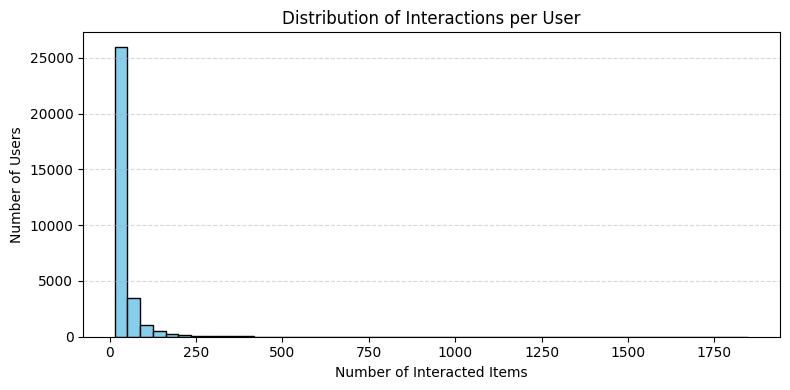

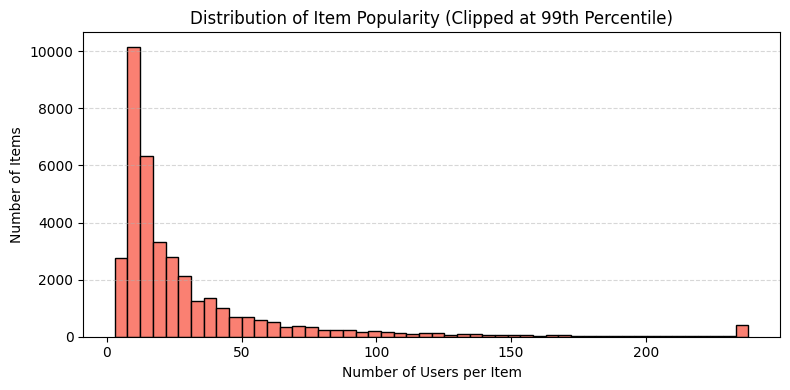

Train interactions: 1111523
Validation pairs: 125369

Training BASE ALS (factors=64, reg=0.01, alpha=40) with loss tracking...


100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


BASE ALS NDCG@20: 0.03905893176818127

Training ALS TWEAK 1 with loss tracking...


100%|██████████| 1/1 [00:00<00:00,  1.07it/s]


ALS TWEAK 1 NDCG@20: 0.04189704022096375

Applying BM25 weighting for ALS TWEAK 2...
Training ALS TWEAK 2 (BM25) with loss tracking...


100%|██████████| 1/1 [00:00<00:00,  1.38it/s]


ALS TWEAK 2 (BM25) NDCG@20: 0.030545273626034375


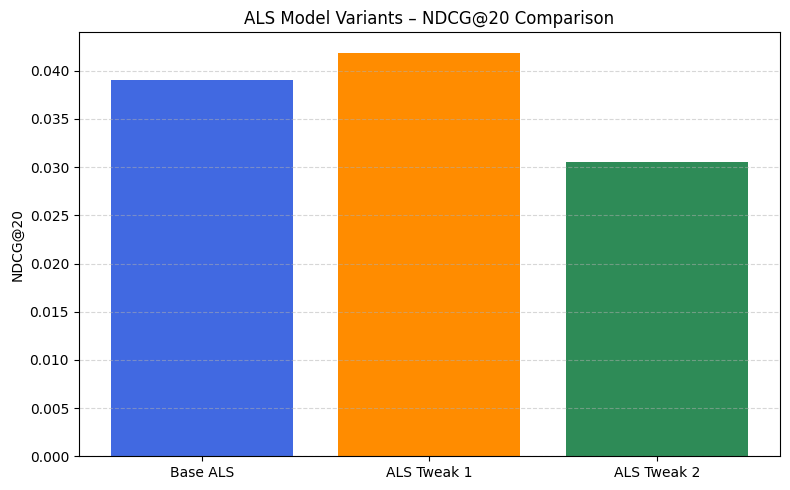

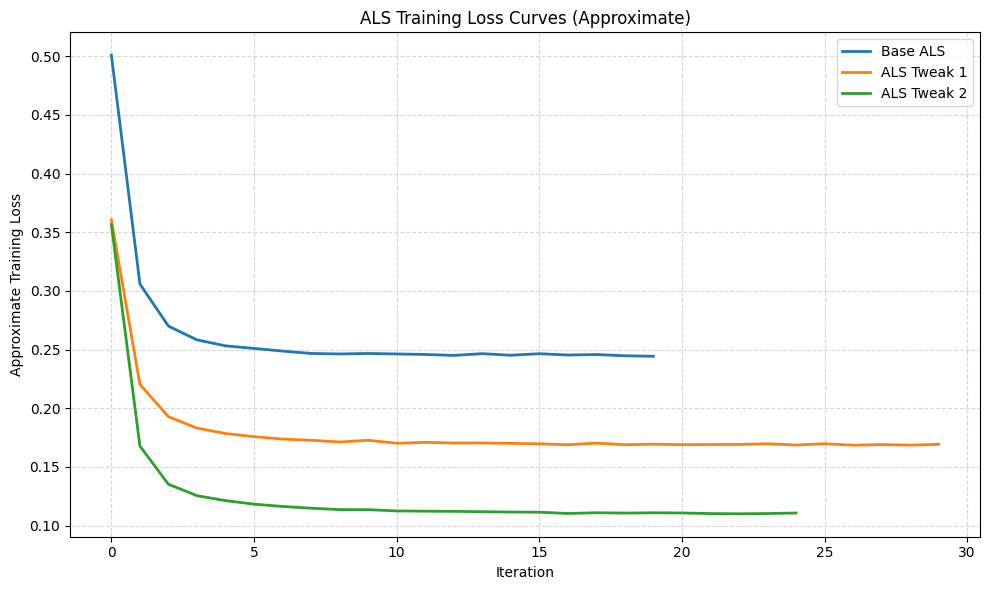


Validation NDCG scores: {'BASE': 0.03905893176818127, 'TWEAK1': 0.04189704022096375, 'TWEAK2': 0.030545273626034375}
Best ALS variant on validation: TWEAK1

Retraining best ALS variant (TWEAK1) on FULL data with params: {'factors': 128, 'reg': 0.05, 'iterations': 30, 'alpha': 40.0}


100%|██████████| 30/30 [00:28<00:00,  1.03it/s]


submission.txt saved to submission.txt


In [26]:
if __name__ == "__main__":
    # 1) Load data
    print("Loading data...")
    user_item_full, user_items_full, inv_user_full, inv_item_full = load_interactions(DATA_PATH)
    n_users, n_items_full = user_item_full.shape
    print(f"Loaded: {user_item_full.nnz} interactions")
    print(f"Users: {n_users}, Items (before preprocessing): {n_items_full}")

    # 2) Preprocess (remove rare items)
    user_item, inv_item = preprocess_data(user_item_full, inv_item_full, min_item_interactions=3)
    n_users, n_items = user_item.shape
    print(f"Users: {n_users}, Items (after preprocessing): {n_items}")

    # 3) Build user_items and EDA graphs
    user_items = build_user_items_from_user_item(user_item)
    plot_eda_graphs(user_items, user_item)

    # 4) Train/val split
    train_user_item, train_user_items, val_pairs = train_val_split_90_10(
        user_items, n_users, n_items, VAL_FRAC
    )
    print(f"Train interactions: {train_user_item.nnz}")
    print(f"Validation pairs: {len(val_pairs)}")

    # 5) Train BASE ALS
    print("\nTraining BASE ALS (factors=64, reg=0.01, alpha=40) with loss tracking...")

    losses_base = []
    model_base = implicit.als.AlternatingLeastSquares(
        factors=64,
        regularization=0.01,
        iterations=1,
        random_state=42
    )

    for iter in range(20):   # 20 ALS iterations
        model_base.fit(train_user_item * 40)  # alpha = 40
        loss = approximate_loss(model_base, train_user_item, alpha=40)
        losses_base.append(loss)

    als_base = model_base  # rename for consistency

    rec_base = make_recommender(als_base, train_user_item, train_user_items)
    ndcg_base = evaluate_model_ndcg20(rec_base, val_pairs)
    print("BASE ALS NDCG@20:", ndcg_base)


    # 6) Train ALS TWEAK 1
    print("\nTraining ALS TWEAK 1 with loss tracking...")

    losses_tweak1 = []
    model_t1 = implicit.als.AlternatingLeastSquares(
        factors=128,
        regularization=0.05,
        iterations=1,
        random_state=42
    )

    for iter in range(30):   # 30 iterations for tweak 1
        model_t1.fit(train_user_item * 40)
        loss = approximate_loss(model_t1, train_user_item, alpha=40)
        losses_tweak1.append(loss)

    als_tweak1 = model_t1

    rec_tweak1 = make_recommender(als_tweak1, train_user_item, train_user_items)
    ndcg_tweak1 = evaluate_model_ndcg20(rec_tweak1, val_pairs)
    print("ALS TWEAK 1 NDCG@20:", ndcg_tweak1)


    # 7) Train ALS TWEAK 2 (BM25)
    print("\nApplying BM25 weighting for ALS TWEAK 2...")

    # Step 1 — Create BM25 weighted USER–ITEM matrix
    bm25_item_user = bm25_weight(train_user_item.T.tocsr(), K1=100, B=0.8)
    train_user_item_bm25 = bm25_item_user.T.tocsr()

    print("Training ALS TWEAK 2 (BM25) with loss tracking...")

    # Step 2 — Loss tracking
    losses_tweak2 = []
    model_t2 = implicit.als.AlternatingLeastSquares(
        factors=96,
        regularization=0.03,
        iterations=1,
        random_state=42
    )

    for itr in range(25):
        model_t2.fit(train_user_item_bm25 * 20)   # alpha=20
        loss = approximate_loss(model_t2, train_user_item_bm25, alpha=20)
        losses_tweak2.append(loss)

    als_tweak2 = model_t2

    # Step 3 — Evaluate
    rec_tweak2 = make_recommender(als_tweak2, train_user_item_bm25, train_user_items)
    ndcg_tweak2 = evaluate_model_ndcg20(rec_tweak2, val_pairs, k=K_RECS)
    print("ALS TWEAK 2 (BM25) NDCG@20:", ndcg_tweak2)



    # 8) Graph – NDCG comparison
    models = ["Base ALS", "ALS Tweak 1", "ALS Tweak 2"]
    scores = [ndcg_base, ndcg_tweak1, ndcg_tweak2]

    plt.figure(figsize=(8, 5))
    plt.bar(models, scores, color=["royalblue", "darkorange", "seagreen"])
    plt.ylabel("NDCG@20")
    plt.title("ALS Model Variants – NDCG@20 Comparison")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # loss curve
    plt.figure(figsize=(10,6))
    plt.plot(losses_base, label="Base ALS", linewidth=2)
    plt.plot(losses_tweak1, label="ALS Tweak 1", linewidth=2)
    plt.plot(losses_tweak2, label="ALS Tweak 2", linewidth=2)
    plt.xlabel("Iteration")
    plt.ylabel("Approximate Training Loss")
    plt.title("ALS Training Loss Curves (Approximate)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()



    # 9) Pick best model
    scores_dict = {
        "BASE": ndcg_base,
        "TWEAK1": ndcg_tweak1,
        "TWEAK2": ndcg_tweak2,
    }
    print("\nValidation NDCG scores:", scores_dict)

    best_name = max(scores_dict, key=scores_dict.get)
    print(f"Best ALS variant on validation: {best_name}")

    if best_name == "BASE":
        best_matrix_full = user_item
        best_params = dict(factors=64, reg=0.01, iterations=20, alpha=40.0)
    elif best_name == "TWEAK1":
        best_matrix_full = user_item
        best_params = dict(factors=128, reg=0.05, iterations=30, alpha=40.0)
    else:
        # BM25 on full USER–ITEM matrix (ensure CSR)
        bm25_item_user_full = bm25_weight(user_item.T.tocsr(), K1=100, B=0.8)
        best_matrix_full = bm25_item_user_full.T.tocsr()  # (n_users x n_items), CSR
        best_params = dict(factors=96, reg=0.03, iterations=25, alpha=20.0)

    print(f"\nRetraining best ALS variant ({best_name}) on FULL data with params: {best_params}")

    best_model = train_als(
        best_matrix_full,
        factors=best_params["factors"],
        reg=best_params["reg"],
        iterations=best_params["iterations"],
        alpha=best_params["alpha"],
    )

    # 10) Generate submission file
    generate_submission(best_model, best_matrix_full, inv_user_full, inv_item)
